# Use this notebook to visualise subsets/instantaneous data

### Imports + csv paths

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
plt.style.use('seaborn')


/var/folders/n_/64hnj2wj2z9bjdmhv2pyfz6h0000gp/T/ipykernel_66527/2903987102.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [5]:
led_csv = pd.read_csv("./data/output/LED_times.csv")


In [6]:
csv_path = Path("./data/output/final")
csv_files = list(csv_path.glob("**/*.csv"))
print(len(csv_files), "csv files found")

241 csv files found


### Setup instantaneuos LED analysis df

In [19]:
data = {"name": [], "uroa_control":[], "day":[], 'dist' : [], "vel" : [], "acc" : [], "angle" : [], "dist_surface": []}
for csv in csv_files:
    print(csv.name)
    led_row = led_csv[led_csv["name"].str.contains(csv.stem)]
    if led_row.empty:
        print(f"LED file not found for {csv.name}")
    else:
        df = pd.read_csv(csv)
        start_frame, end_frame = led_row["start frame"].values[0] - 1, led_row["end frame"].values[0] - 1 # -1 because of 0 indexing
        # print(start_frame, end_frame)
        name = csv.stem.split("_")[0]
        data["name"].append(name)
        control_uro = 1 if "uro" in str(csv) else 0
        data["uroa_control"].append(control_uro)
        day = csv.parent.name
        data["day"].append(int(day))
        dist = df.loc[start_frame:end_frame, "avg_dist_vel"].sum()
        data["dist"].append(dist)
        avg_vel = df.loc[start_frame:end_frame, "avg_dist_vel"].mean()
        data["vel"].append(avg_vel)
        avg_acc = df.loc[start_frame:end_frame, "avg_acc"].mean()
        data["acc"].append(avg_acc)
        avg_angle = df.loc[start_frame:end_frame, "angle"].mean()
        data["angle"].append(avg_angle)
        avg_dist_surface = df.loc[start_frame:end_frame, "distance_surface"].max()
        data["dist_surface"].append(avg_dist_surface)
print(data)
for key, value in data.items():
    print(key, len(value))
df = pd.DataFrame(data)
print(df.head(5))



101_M.csv
144_M.csv
116_T.csv
125_M.csv
LED file not found for 125_M.csv
114_T.csv
LED file not found for 114_T.csv
103_M.csv
146_M.csv
LED file not found for 146_M.csv
142_M.csv
159_M.csv
105_M.csv
126_M.csv
115_T.csv
LED file not found for 115_T.csv
120_M.csv
158_M.csv
139_M.csv
113_T.csv
LED file not found for 113_T.csv
104_M.csv
LED file not found for 104_M.csv
122_M.csv
137_M.csv
108_M.csv
150_M.csv
128_M.csv
149_M.csv
133_M.csv
LED file not found for 133_M.csv
155_M.csv
157_M.csv
121_T.csv
LED file not found for 121_T.csv
153_M.csv
129_M.csv
130_M.csv
148_M.csv
155_S.csv
157_S.csv
LED file not found for 157_S.csv
113_SU.csv
153_S.csv
129_S.csv
130_S.csv
LED file not found for 130_S.csv
148_S.csv
LED file not found for 148_S.csv
137_S.csv
108_S.csv
150_S.csv
128_S.csv
149_S.csv
133_S.csv
115_SU.csv
LED file not found for 115_SU.csv
126_S.csv
122_F.csv
LED file not found for 122_F.csv
158_S.csv
139_S.csv
104_S.csv
120_F.csv
144_S.csv
101_S.csv
125_S.csv
LED file not found for 125_S

### Distance/Vel and acceleration box plot

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

1
Empty DataFrame
Columns: [day, uroa_control, dist]
Index: []
Series([], Name: dist, dtype: float64)
Series([], Name: dist, dtype: float64)
2
Empty DataFrame
Columns: [day, uroa_control, dist]
Index: []
Series([], Name: dist, dtype: float64)
Series([], Name: dist, dtype: float64)
3
Empty DataFrame
Columns: [day, uroa_control, dist]
Index: []
Series([], Name: dist, dtype: float64)
Series([], Name: dist, dtype: float64)
4
Empty DataFrame
Columns: [day, uroa_control, dist]
Index: []
Series([], Name: dist, dtype: float64)
Series([], Name: dist, dtype: float64)
1
Empty DataFrame
Columns: [day, uroa_control, vel]
Index: []
Series([], Name: vel, dtype: float64)
Series([], Name: vel, dtype: float64)
2
Empty DataFrame
Columns: [day, uroa_control, vel]
Index: []
Series([], Name: vel, dtype: float64)
Series([], Name: vel, dtype: float64)
3
Empty DataFrame
Columns: [day, uroa_control, vel]
Index: []
Series([], Name: vel, dtype: float64)
Series([], Name: vel, dtype: float64)
4
Empty DataFrame
Colu

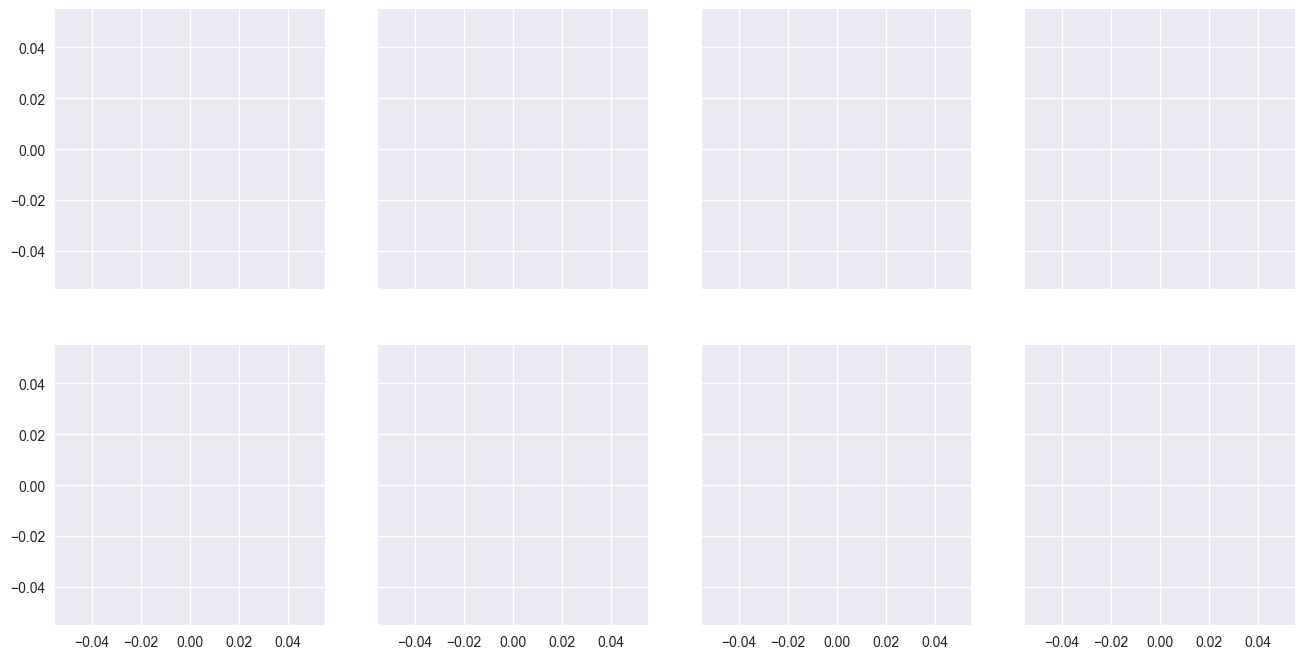

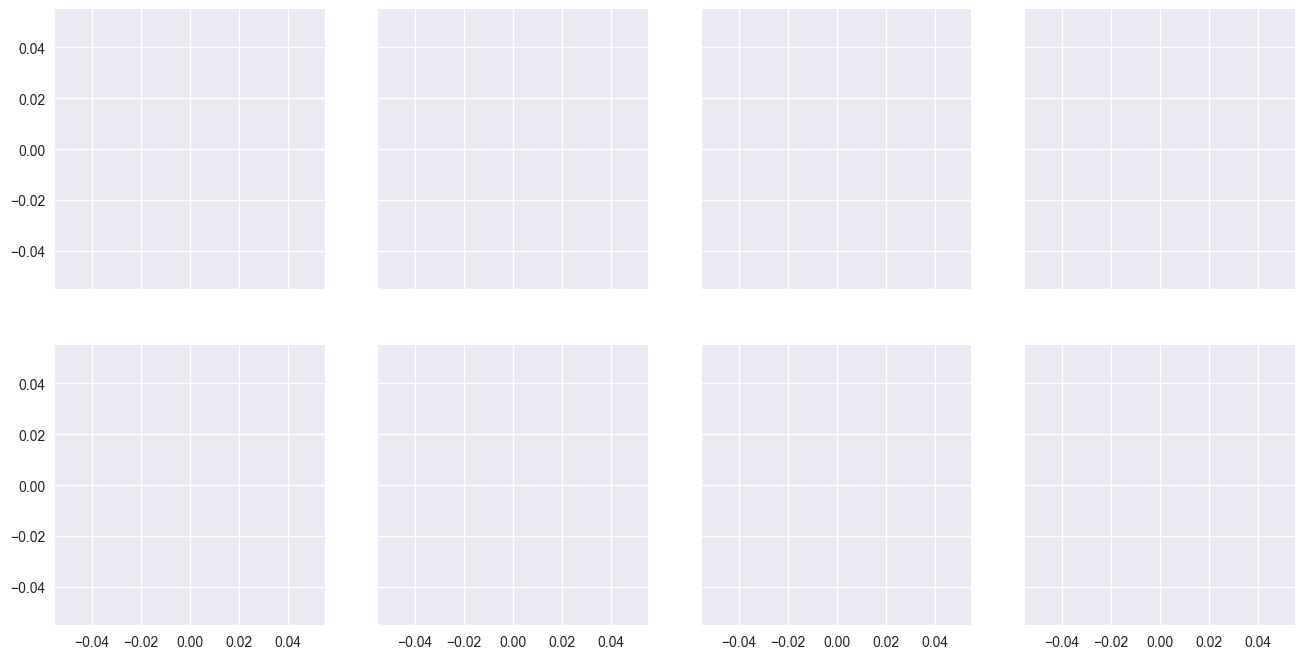

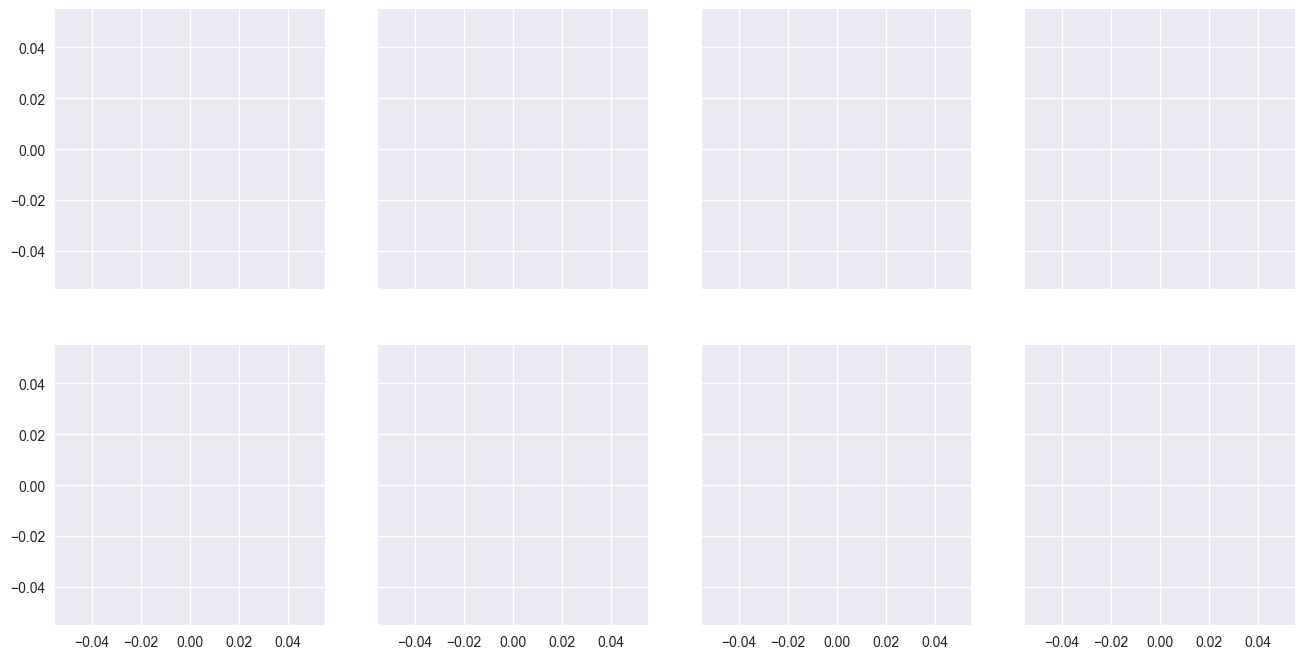

In [77]:
# create plot for each day in range 1-4, control vs uroa
for var in ["dist", "vel", "acc"]:
    var_df = df[["day", "uroa_control", var]]
    fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
    for day in range(1,5):
        print(day)
        # plt.figure()
        # day_df = df[df["day"] == str(day)]
        day_df = var_df[var_df["day"] == str(day)]
        print(day_df.head(5))
        control_df = day_df[day_df["uroa_control"] == 0][var]
        uroa_df = day_df[day_df["uroa_control"] == 1][var]
        print(control_df.head(5))
        print(uroa_df.head(5))
        # plt.figure()
        sns.histplot(control_df, label=f"{var}_{day}_control", ax=axes[0, day-1], bins = 20)
        plt.legend()
        
        # sns.histplot(uroa_df, label="uroa")
        # plt.figure()
        sns.histplot(uroa_df, label=f"{var}_{day}_uroa", ax=axes[1, day-1], bins=20)
        plt.legend()
plt.show()

In [13]:
dist_vel_acc_df = df[["day", "uroa_control", "dist", "vel", "acc"]].groupby(["uroa_control", "day"])
keys = list(dist_vel_acc_df.groups.keys())
keys.remove((0, 5))
keys.remove((1, 5))
for key in keys:
    print(key)
    df = dist_vel_acc_df.get_group(key)
    print(len(df))
    


(0, 1)
25
(0, 2)
23
(0, 3)
21
(0, 4)
22
(1, 1)
23
(1, 2)
21
(1, 3)
22
(1, 4)
23


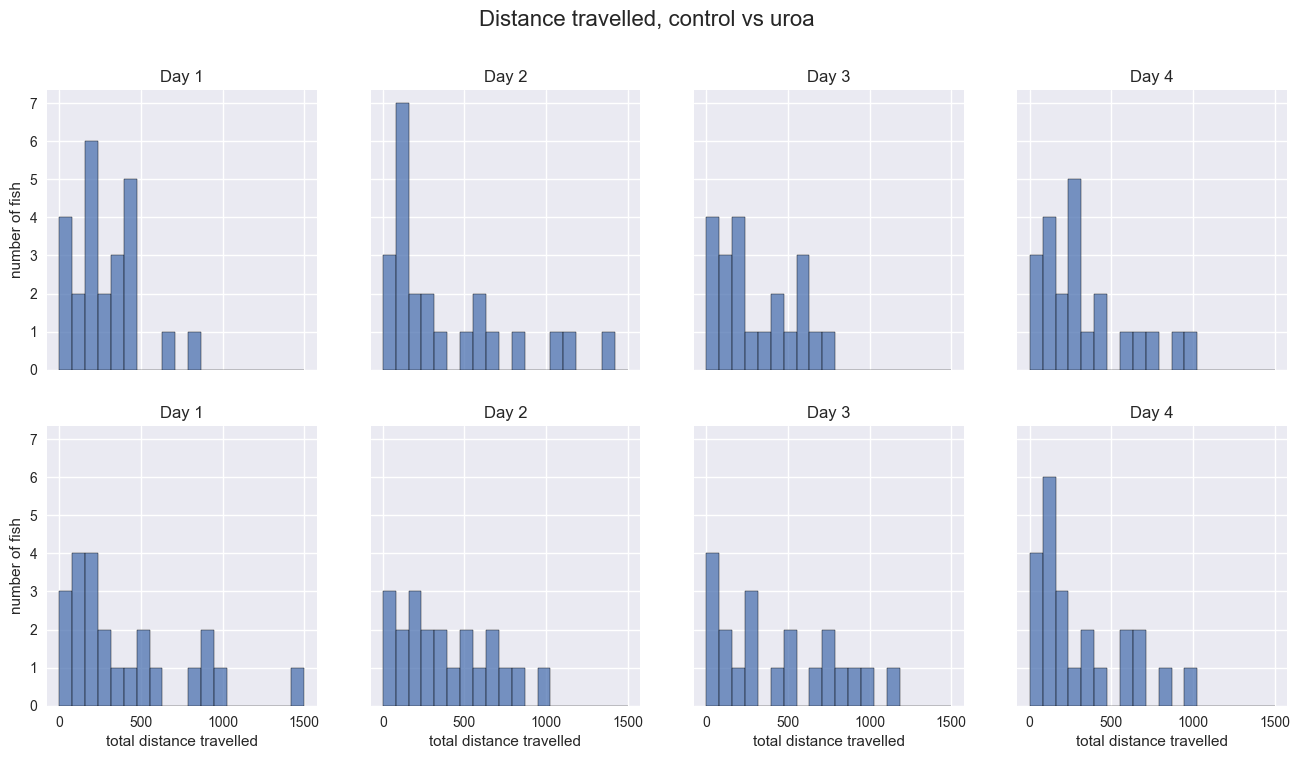

In [14]:
# for distance plots
fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("Distance travelled, control vs uroa", fontsize=16) 
for i, axes in enumerate(axes.flat):
    key = keys[i]
    day_df = dist_vel_acc_df.get_group(key)
    bins = np.linspace(0, 1500, 20)
    # print(day_df.head(5))
    sns.histplot(day_df["dist"],  ax=axes, bins = bins)
    axes.set_title(f"Day {key[1]}")
    axes.set_xlabel("total distance travelled")
    axes.set_ylabel("number of fish")

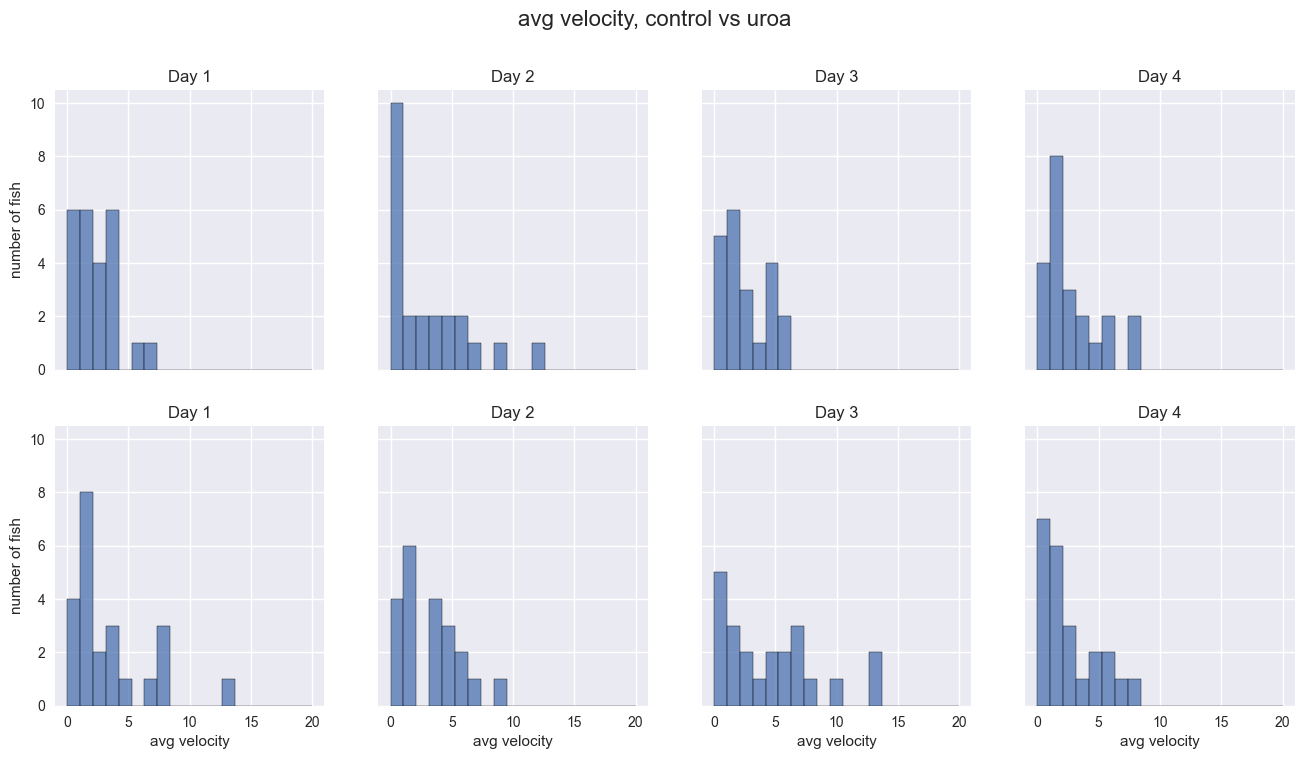

In [15]:
# for vel plots
fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("avg velocity, control vs uroa", fontsize=16) 
for i, axes in enumerate(axes.flat):
    key = keys[i]
    day_df = dist_vel_acc_df.get_group(key)
    bins = np.linspace(0, 20, 20)
    # print(day_df.head(5))
    sns.histplot(day_df["vel"], ax=axes, bins = bins)
    axes.set_title(f"Day {key[1]}")
    axes.set_xlabel("avg velocity")
    axes.set_ylabel("number of fish")

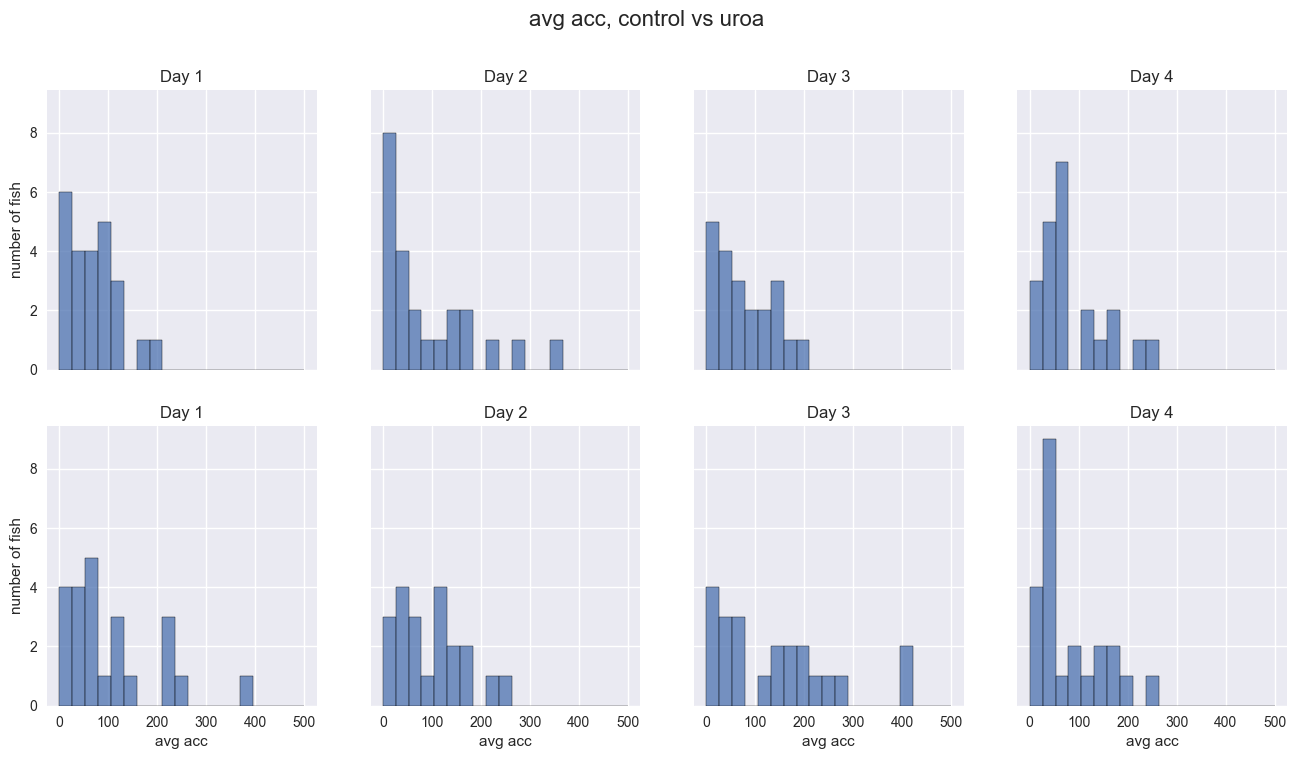

In [16]:
# for acc plots
fig, axes = plt.subplots(2, 4, sharex=True, sharey = True, figsize=(16,8))
plt.suptitle("avg acc, control vs uroa", fontsize=16) 
for i, axes in enumerate(axes.flat):
    key = keys[i]
    day_df = dist_vel_acc_df.get_group(key)
    bins = np.linspace(0, 500, 20)
    # print(day_df.head(5))
    sns.histplot(day_df["acc"], ax=axes, bins = bins)
    axes.set_title(f"Day {key[1]}")
    axes.set_xlabel("avg acc")
    axes.set_ylabel("number of fish")

### Polar plots

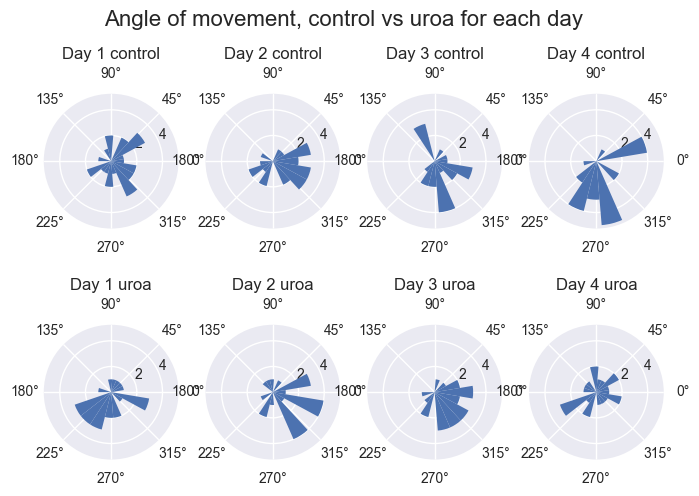

In [20]:
#create a separate polar plot for each day
fig, axs = plt.subplots(2, 4, subplot_kw=dict(projection='polar'), sharex=True, sharey=True)
plt.suptitle("Angle of movement, control vs uroa for each day", fontsize=16)
angle_df = df[["day", "uroa_control", "angle"]].groupby(["uroa_control","day" ])
keys = list(angle_df.groups.keys())
# remove the keys for day 5
keys.remove((0,5))
keys.remove((1,5)) 
for i, ax in enumerate(axs.flat):
    group = angle_df.get_group(keys[i])
    angles = group["angle"].apply(lambda x: x * (np.pi) / 180)  # convert to radians
    bins = np.linspace(-np.pi, np.pi, num=20)
    ax.hist(angles, bins=bins)
    ax.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}")

plt.show()
    